# Phase III: First ML Proof of Concept

### Team Members: Kaung Mo, Ian Menachery, Komal Jain, Sunithi Krishnan

## TODO

- Maybe full data residuals
- Maybe full data model application + pred values plot
- More ethical considerations

### Ethical Considerations
Before we begin working with the data, some ethical concerns should be noted. The data that we are using for our project is from imdb Api which gives us information about movies like genre, directors, writers, actors, and most importantly, the movie's rating. However, this data does generate some level of concerns about ethicality.    

The first concern is about the manner in which IMDB generates ratings. IMDB collects ratings by allowing registered users to rate movies on a scale of 1 to 10. This could "review bombings" where the movie producers' competitors could arrange for a group of users to send a flurry of negative reviews towards a movie. Furthermore, both the movie's producers and the producers' competitors could pay a set of users or lobby users to leave positive or negative reviews on the movie which could influence the movie's rating. For example, a few years ago, Rotten Tomatoes, a similar site, was busted for allowing critics to pay users to positively influence a movie's rating.  Additionally, movies with controversial topics could be rated differently than uncontroversial movies on the site simply based on the movie's topic which adds a level of bias into the ratings. 

The other main concern is a lack of means to check the demographic breakdown of the ratings. This could lead to the over or under representation of certain groups which could lead to an inaccurate rating that is reflected as how the public views a movie.  

However, in regard to general ethical concerns, the api allows all users to be anonymous, so there is no personal data that can be revealed from the api which removes all of the more general ethical concerns. 

### Choice of Input and Output

We chose to use Genre, Rotten Tomatoes Score and Box Office Earnings because these factors would most likely affect the IMDb rating the most. When choosing a movie to watch, a lot of viewers will base their judgement off genre, as some genres have reputations of being better or worse. For example, in recent years, the Action genre has been overpopulated with Superhero films, which have a negative reputation for being cash grabs. On the other hand, genres such as Thrillers and Dramas are consistently rated higher because it is much easier for these types of films to be personal and have a lasting impact on viewers. Rotten Tomatoes Score is another important influence on IMDb, because there is might be a relation between critic scores given on Rotten Tomatoes, to the user scores given on IMDb. Most the times, ratings between critics and users are similar for good movies, so we are trying to see what speicifc relationship there is between the two types of audiences and platforms. Finally, Box Office Earnings is an important factor to consider because the popularity of a movie may correlate with how much the movie is liked by viewers. Therefore we want to see if there is a linear relation with these two factors, because we predict that the better the movie, the more popular it should be. Out of all the variables, the three described above made sense as most impactful to IMDb score at face value. Values such as Directors and Actors were hard to quantify because there are thousands of different actors and directors, so it would be inefficient to one-hot encode those categories. Year, age rating, and runtime were considered, but we believe our chosen variables will have a closer correlation to IMDb ratings. 

We chose the IMDb score as output because we want to see what makes up the user score of movies (compared to critic score) because we want to see if there are major patterns in the movie industry that influences what makes a good movie and what doesn't.

### Assumption Analysis

When using linear regression, there are a few important assumptions to keep in mind to make sure the model works properly.
1. The data points should be independent, meaning that one observation shouldn’t influence another.
2. There needs to be a linear relationship between the independent variables (predictors) and the dependent variable (target). If the relationship isn’t linear, the model might not give accurate predictions.
3. The model assumes homoscedasticity, which means that the spread of the residuals (the difference between actual and predicted values) should stay constant across all predicted values.
4. The normality assumption means that the residuals should follow a normal distribution.

Residuals were calculated using the test data set, because it is much more helpllful 

In [6]:
import pandas as pd

# Replace 'your_file.csv' with the path to your CSV file
file_path = 'movies_output_clean.csv'

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(file_path)

df_first = df[['Genre', 'RottenTomatoesScore (%)', 'BoxOfficeEarnings ($)', 'IMDbRating']]

df_drops = df_first.dropna()
# After dropping instances of we are left with 732 movies

display(df.head())
df_drops

,Title,Year,Rated,ReleaseDate,Runtime (min),Genre,Director,Writer,Actors,Plot,Language,Country,Awards,IMDRating (out of 10),RottenTomatoesScore (%),IMDbRating,IMDbVotes,BoxOfficeEarnings ($)
0,Venom: The Last Dance,2024.0,PG-13,2024-10-25,109.0,"Action, Adventure, Sci-Fi",Kelly Marcel,"Kelly Marcel, Tom Hardy","Tom Hardy, Juno Temple, Alanna Ubach",Eddie and Venom are on the run. Hunted by both...,English,"United States, United Kingdom, Mexico",NaN,NaN,41.0,NaN,NaN,NaN
1,Terrifier 3,2024.0,Not Rated,2024-10-11,125.0,Horror,Damien Leone,Damien Leone,"Lauren LaVera, David Howard Thornton, Antonell...",Art the Clown is set to unleash chaos on the u...,English,United States,NaN,6.7,77.0,6.7,18437.0,45670161.0
2,The Wild Robot,2024.0,PG,2024-09-27,102.0,"Animation, Sci-Fi",Chris Sanders,"Chris Sanders, Peter Brown","Lupita Nyong'o, Pedro Pascal, Kit Connor","After a shipwreck, an intelligent robot called...",English,"United States, Japan",3 wins & 2 nominations,8.3,98.0,8.3,80239.0,137913995.0
3,Deadpool,2016.0,R,2016-02-12,108.0,"Action, Comedy",Tim Miller,"Rhett Reese, Paul Wernick","Ryan Reynolds, Morena Baccarin, T.J. Miller",A wisecracking mercenary gets experimented on ...,English,United States,29 wins & 78 nominations,8.0,85.0,8.0,1174691.0,363070709.0
4,Smile 2,2024.0,R,2024-10-18,127.0,"Horror, Mystery, Thriller",Parker Finn,Parker Finn,"Naomi Scott, Rosemarie DeWitt, Lukas Gage","About to embark on a world tour, global pop se...",English,"United States, Canada",NaN,7.2,85.0,7.2,21791.0,41787385.0


,Genre,RottenTomatoesScore (%),BoxOfficeEarnings ($),IMDbRating
1,Horror,77.0,45670161.0,6.7
2,"Animation, Sci-Fi",98.0,137913995.0,8.3
3,"Action, Comedy",85.0,363070709.0,8.0
4,"Horror, Mystery, Thriller",85.0,41787385.0,7.2
5,"Drama, Horror",90.0,16235191.0,7.5
...,...,...,...,...
995,"Action, Comedy, Crime",60.0,186336279.0,6.5
996,"Action, Comedy, Crime",71.0,127440871.0,6.3
997,Comedy,47.0,72217396.0,6.9
998,"Action, Adventure, Family",49.0,93436322.0,6.4


In [7]:
import numpy as np
import pandas as pd

# Preprocess the DataFrame (same as before)
df_x = df_drops[['Genre', 'RottenTomatoesScore (%)', 'BoxOfficeEarnings ($)']].copy()
df_x['Genre'] = df_x['Genre'].str.split(',').str[0].str.strip()

df_combined = pd.concat([df_x, df_drops['IMDbRating']], axis=1)
df_combined = df_combined.dropna()
df_combined['BoxOfficeEarnings ($)'] = np.log1p(df_combined['BoxOfficeEarnings ($)'])

genre_encoded = pd.get_dummies(df_combined['Genre'], prefix='Genre', dtype=np.float64)
df_x_encoded = pd.concat([df_combined[['RottenTomatoesScore (%)', 'BoxOfficeEarnings ($)']], genre_encoded], axis=1)

X = df_x_encoded.to_numpy(dtype=np.float64)
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0, ddof=0)
X_std[X_std == 0] = 1
X_scaled = (X - X_mean) / X_std

y = df_combined['IMDbRating'].to_numpy()
split_index = int(len(X_scaled) * 0.7) # 70 to 30 training test split
Xtrain, Xtest = X_scaled[:split_index], X_scaled[split_index:]
ytrain, ytest = y[:split_index], y[split_index:]

# Add intercept term to features
Xtrain = np.hstack([np.ones((Xtrain.shape[0], 1)), Xtrain])
Xtest = np.hstack([np.ones((Xtest.shape[0], 1)), Xtest])

# Ridge Regression
def ridge_regression(X, y, alpha):
    n_features = X.shape[1]
    identity = np.eye(n_features)
    identity[0, 0] = 0  # Don't penalize the intercept
    theta = np.linalg.inv(X.T @ X + alpha * identity) @ X.T @ y
    return theta


# Apply Ridge
alpha = 1.0  # Regularization strength
ridge_theta = ridge_regression(Xtrain, ytrain, alpha)
ridge_pred = Xtest @ ridge_theta
ytrain_ridge_pred = Xtrain @ ridge_theta


# Evaluation
def evaluate_model(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    ss_total = np.sum((y_true - np.mean(y_true)) ** 2)
    ss_residual = np.sum((y_true - y_pred) ** 2)
    r2 = 1 - (ss_residual / ss_total)
    return mse, r2

ridge_mse, ridge_r2 = evaluate_model(ytest, ridge_pred)

print("Ridge Regression:")
print(f"MSE: {ridge_mse}")
print(f"R²: {ridge_r2}")

feature_names = ['Intercept'] + df_x_encoded.columns.tolist()

# Ridge Coefficients
ridge_coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ridge_theta
}).sort_values(by='Coefficient', key=abs, ascending=False)

ridge_ranked = ridge_coefficients.sort_values(by='Coefficient', ascending=False)

#Calculate Residuals (With test data set)
residuals = ytest- ridge_pred
train_residuals = ytrain - ytrain_ridge_pred

print("Ridge Regression Predictor Rankings:")
print(ridge_ranked[['Feature', 'Coefficient']].round(3))

Ridge Regression:
MSE: 0.3819226436239261
R²: 0.4176150602858868
Ridge Regression Predictor Rankings:
                    Feature  Coefficient
0                 Intercept        6.941
1   RottenTomatoesScore (%)        0.748
2     BoxOfficeEarnings ($)        0.152
6           Genre_Biography        0.082
9               Genre_Drama        0.068
8               Genre_Crime        0.067
7              Genre_Comedy        0.031
10            Genre_Fantasy       -0.000
12            Genre_Mystery       -0.003
4           Genre_Adventure       -0.004
3              Genre_Action       -0.010
13           Genre_Thriller       -0.023
5           Genre_Animation       -0.042
11             Genre_Horror       -0.129



The model explains about 41.8% of the variance in IMDb ratings based on the given predictors. While this indicates a moderate fit, it suggests other unmeasured factors also significantly influence IMDb ratings.

for every 1% increase in Rotten Tomatoes Score, the predicted IMDb rating increases by approximately 0.748 units, assuming all other variables remain constant.
The boxofficeearnings co efficient of .152 is suprisingly low and suggests the correlation between box office and ratings is lower than we initially thought
This suggests that financial success slightly contributes to audience ratings, likely due to increased visibility or perceived popularity.
some notable features in genre are horror movies have a -.129 coefficient suggesting on average a horror movie has a lower IMDB rating which makes sense.
Horror movies negatively impact IMDb ratings, likely due to polarizing audience preferences or the prevalence of lower-budget productions in this genre.

On the other hand Biographies, dramas, and crimes all have higher scores on avergae by around .07 points on IMDB.
could be because biographical films often focus on compelling real-life stories, which resonate well with audiences.

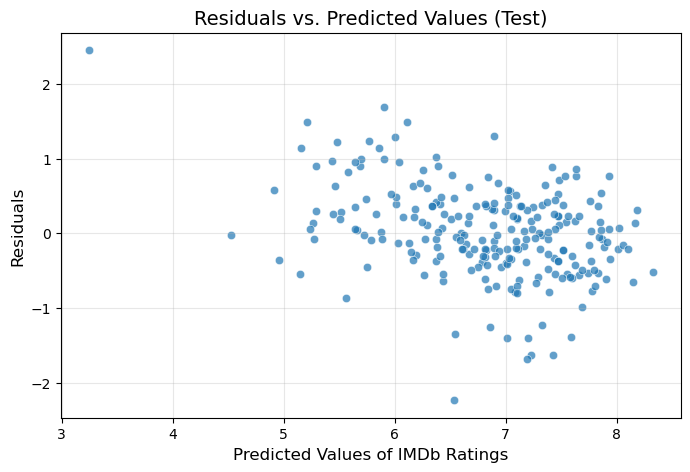

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
#TEST DATA
#Scatterplot for Residuals vs. Predicted Values (IMDb ratings)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=ridge_pred, y=residuals, alpha=0.7)
plt.title("Residuals vs. Predicted Values (Test)", fontsize=14)
plt.xlabel("Predicted Values of IMDb Ratings", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.grid(alpha=0.3)
plt.show()


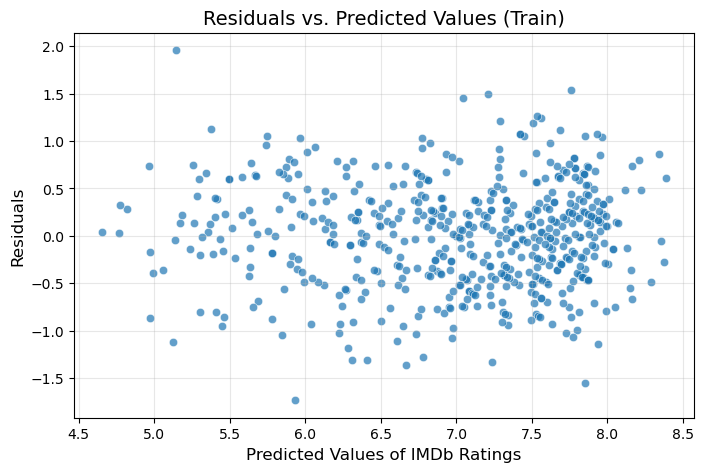

In [10]:
#TRAIN DATA
#Scatterplot for Residuals vs. Predicted Values (IMDb ratings)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=ytrain_ridge_pred, y=train_residuals, alpha=0.7)
plt.title("Residuals vs. Predicted Values (Train)", fontsize=14)
plt.xlabel("Predicted Values of IMDb Ratings", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### Residuals vs. Predicted Values (Constant Variance/Linearity)

The graph shows a random distribution of residuals scattered around y=0. There doesn't look to be any obvious patterns or trends in the residual distribution, proving the assumption of linearity and constant variance. Therefore we can assume that there isn't any non-linear relationships in the data that we missed using the ridge model. The lack of pattern also verifies constant variance, which shows us that there isn't any bias towards certain values that might derail our predicted IMDb ratings and make our output unreliable.

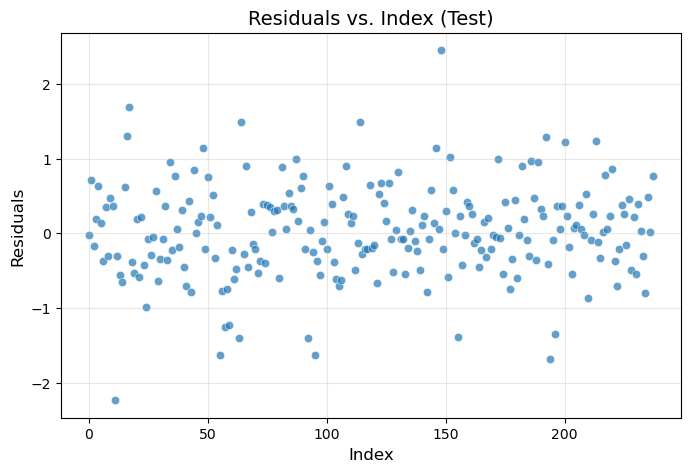

In [12]:
#Scatterplot for Residuals vs. Index
#TEST DATA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=range(len(residuals)), y=residuals, alpha=0.7)
plt.title("Residuals vs. Index (Test)", fontsize=14)
plt.xlabel("Index", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

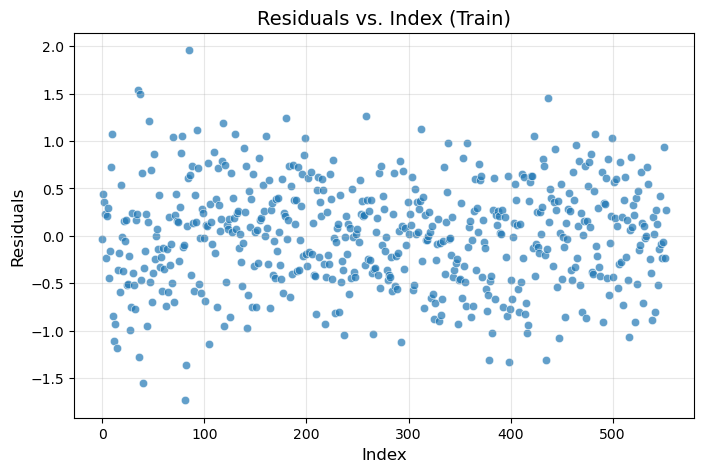

In [13]:
#Scatterplot for Residuals vs. Index
#TRAIN DATA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=range(len(train_residuals)), y=train_residuals, alpha=0.7)
plt.title("Residuals vs. Index (Train)", fontsize=14)
plt.xlabel("Index", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### Residuals vs. Index (Independence)

To verify the assumption of independence in our ridge model, the residuals vs. index graph must show a random distribution of residuals around y=0. The above graph does showcase this property, verifying that the ridge model's residuals aren't related to each other, which shows us that the data collected isn't dependent on previous data. This also means that there is no autocorrelation in the residuals, therefore the data isn't dependent on the sequence of the data itself. If there were patterns in this graph, it could be the effect of a dependence of previous (in terms of index) values in our input data. 

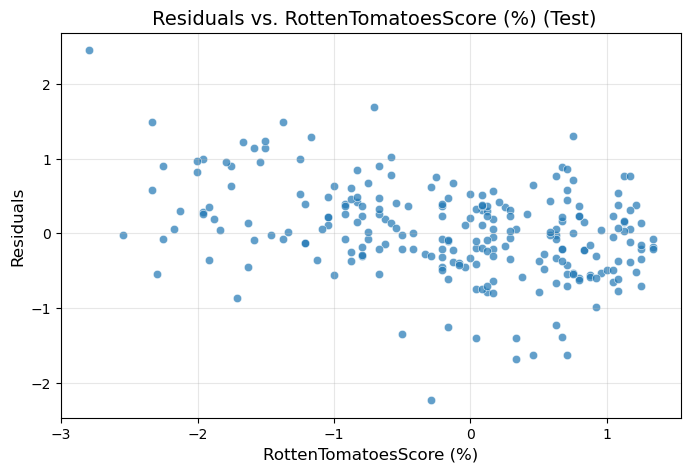

In [15]:
# Scatterplot for Residuals vs. RottenTomatoesScore (%)
#TEST DATA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Xtest[:, 1], y=residuals, alpha=0.7)
plt.title(" Residuals vs. RottenTomatoesScore (%) (Test)", fontsize=14)
plt.xlabel("RottenTomatoesScore (%)", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

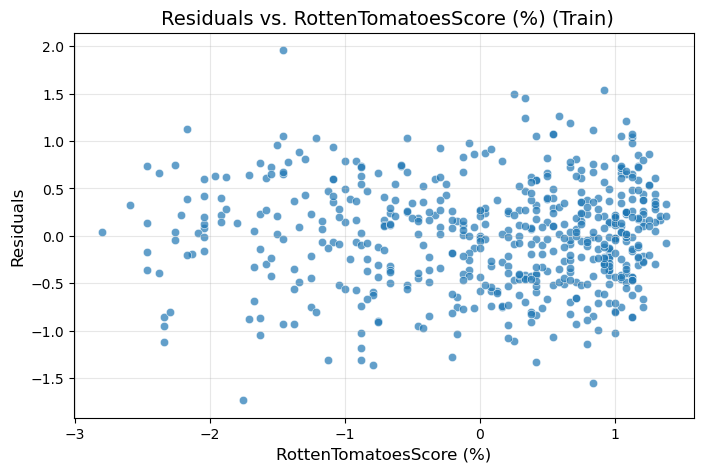

In [16]:
# Scatterplot for Residuals vs. RottenTomatoesScore (%)
#TRAIN DATA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Xtrain[:, 1], y=train_residuals, alpha=0.7)
plt.title(" Residuals vs. RottenTomatoesScore (%) (Train)", fontsize=14)
plt.xlabel("RottenTomatoesScore (%)", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### Residuals vs. RottenTomatoesScore (%)

Comparing residuals to the independent variables enforces the assumption of linearity. Rather than just looking at residuals vs. predicted values, also looking at the relationship between the residuals and each independent variable enforces the linearity of the data, by checking if a certain variable might have non linear trends. In the case of the Rotten Tomatoes score, the residuals are spread out randomly without a pattern, which proves the ridge model's assurance of linearity.

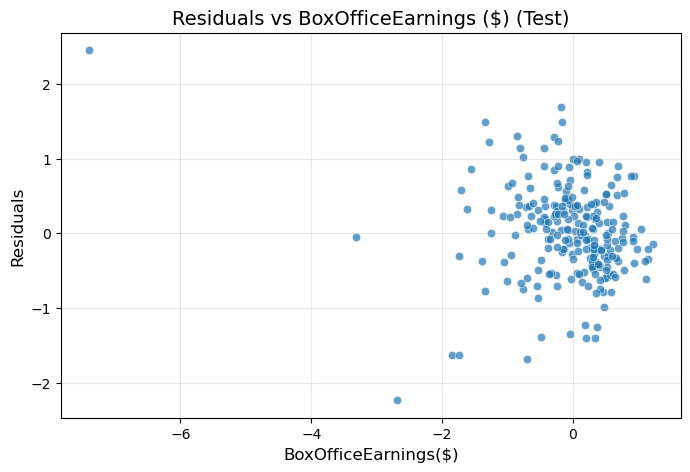

In [18]:
# Scatterplot for Residuals vs BoxOfficeEarnings ($)
#TEST DATA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Xtest[:, 2], y=residuals, alpha=0.7)
plt.title("Residuals vs BoxOfficeEarnings ($) (Test)", fontsize=14)
plt.xlabel("BoxOfficeEarnings($)", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

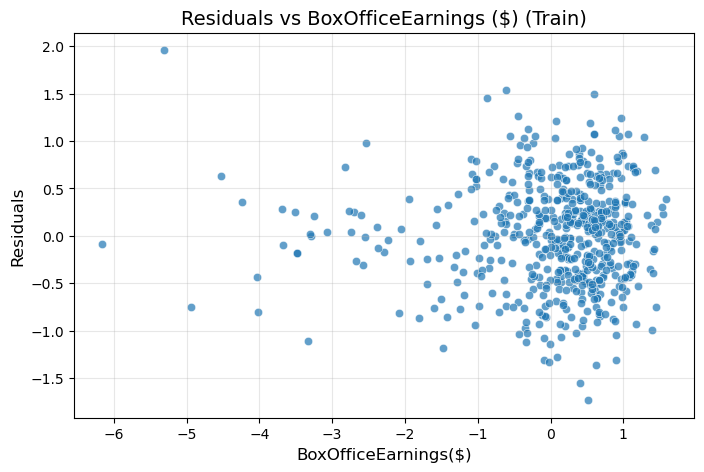

In [19]:
# Scatterplot for Residuals vs BoxOfficeEarnings ($)
#TRAIN DATA
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Xtrain[:, 2], y=train_residuals, alpha=0.7)
plt.title("Residuals vs BoxOfficeEarnings ($) (Train)", fontsize=14)
plt.xlabel("BoxOfficeEarnings($)", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

### Residuals vs. BoxOfficeEarnings ($)

This graph compares box office earnings, an independent variable, to the residuals. There is a clear random scattering of residuals around y=0, which signifies that there were no patterns or relationships not covered by the ridge model pertaining to box office earnings. Therefore, for the majority of data points, the ridge model was accurate in using box office earnings accurately. However, there is a strong focus on x=0, which shows us that the model works well for movies whose box office earnings are near the mean (because the data has been standardized). However, there exist a few outlier towards the negative end, which means the model is less accurate predicting IMDb ratings for movies with abnormal box office earnings. However, this charactersitic can be attritbuted to the subjective nature of movie reception. Some movies are very divisive, causing some viewers to love it, or hate it. Is it also easier for viewers to dislike more popular movies, with the implied reason being that mainstream movies are too basic and surface level. Therefore even if a movie is extremely successful or unscuessful, there is no gurantee that the movies will be rated highly/lowly. 

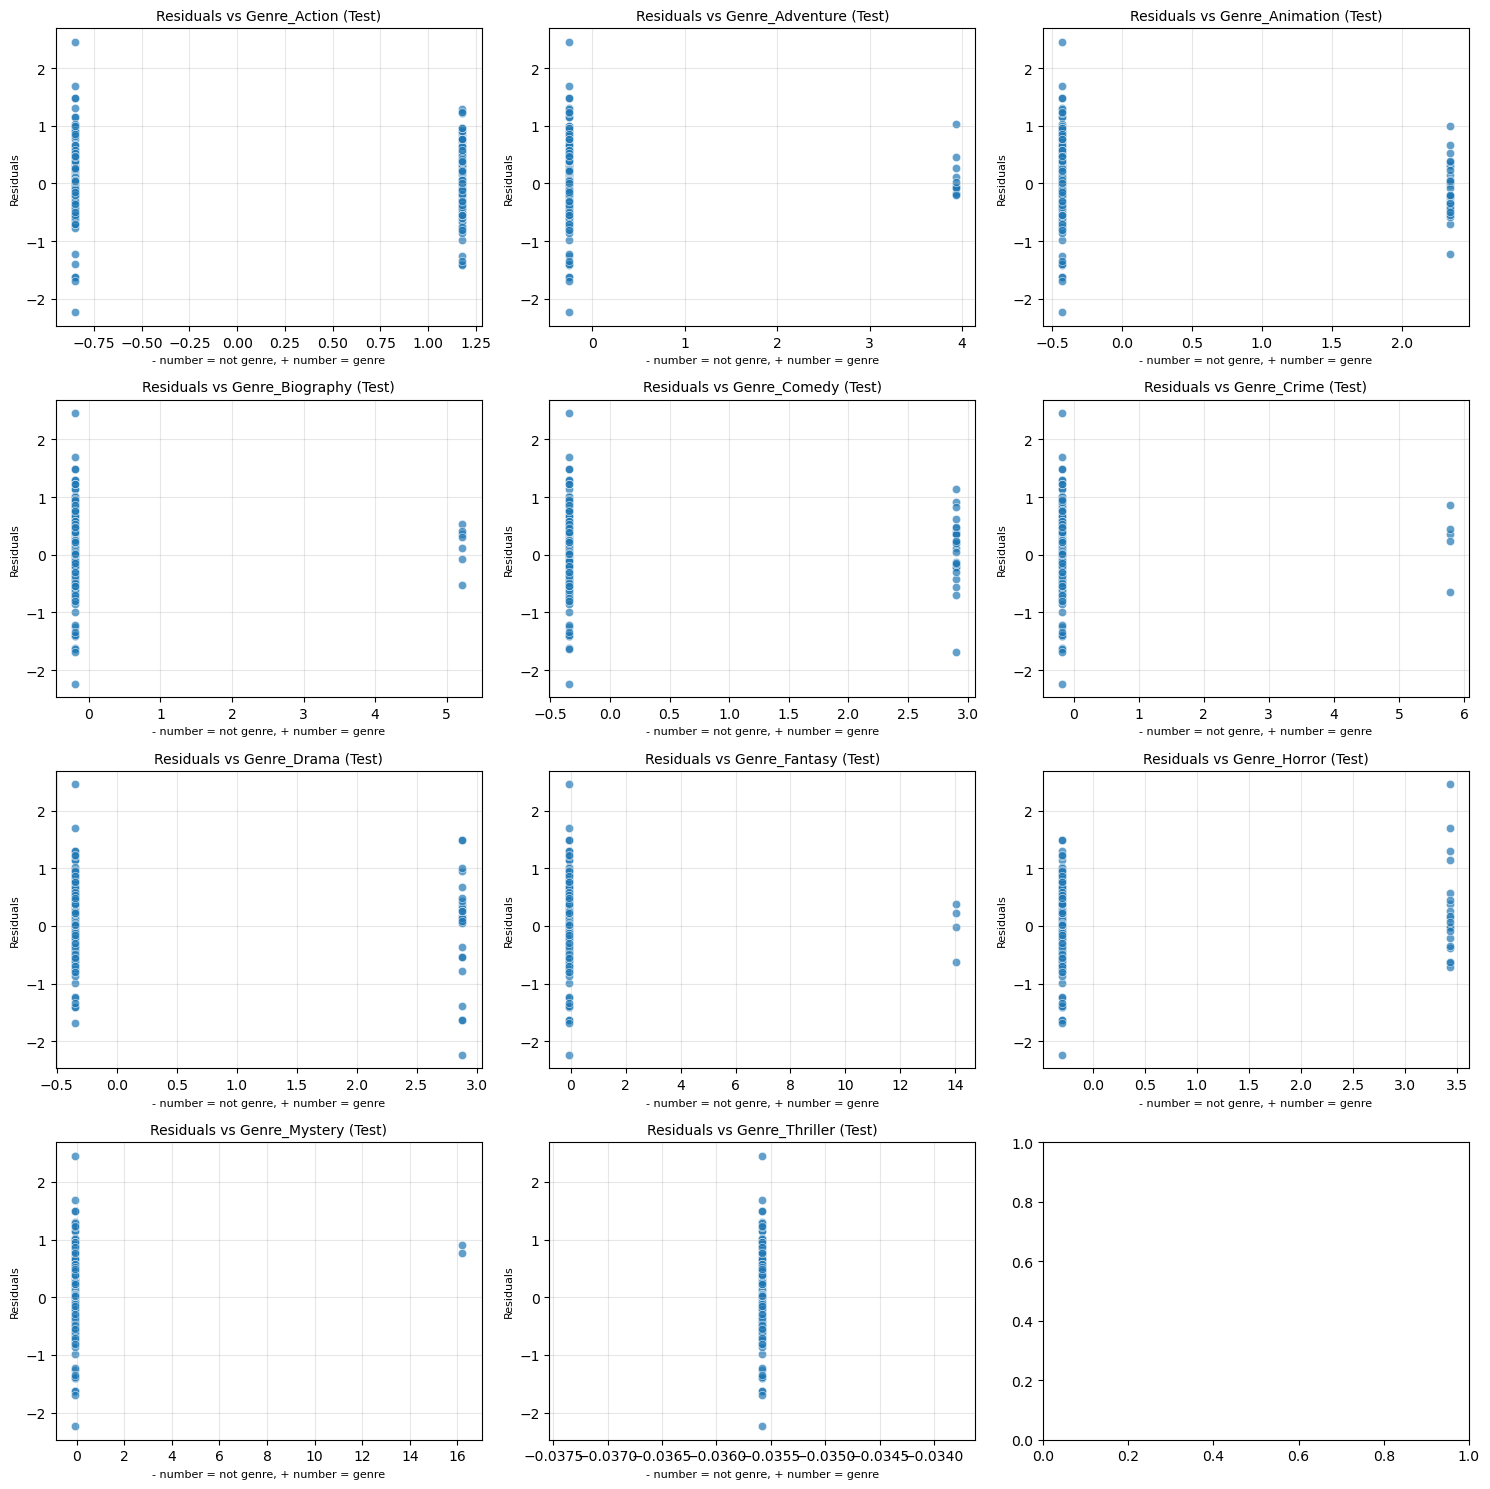

In [21]:
# Scatterplot for Residuals vs Genre
# For each genre, we make a subplot
# TEST DATA
# Make a dictionary with all indexes of Xtest needed and respective genres
genre_indexes = {
    3: 'Genre_Action',
    4: 'Genre_Adventure',
    5: 'Genre_Animation',
    6: 'Genre_Biography',
    7: 'Genre_Comedy',
    8: 'Genre_Crime',
    9: 'Genre_Drama',
    10: 'Genre_Fantasy',
    11: 'Genre_Horror',
    12: 'Genre_Mystery',
    13: 'Genre_Thriller',
}

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, (index, genre) in enumerate(genre_indexes.items()):
    sns.scatterplot(x=Xtest[:, index], y=residuals, alpha=0.7, ax=axes[i])
    axes[i].set_title(f"Residuals vs {genre} (Test)", fontsize=10)
    axes[i].set_xlabel("- number = not genre, + number = genre", fontsize=8)
    axes[i].set_ylabel("Residuals", fontsize=8)
    axes[i].grid(alpha=0.3)
    
plt.tight_layout()
plt.show()


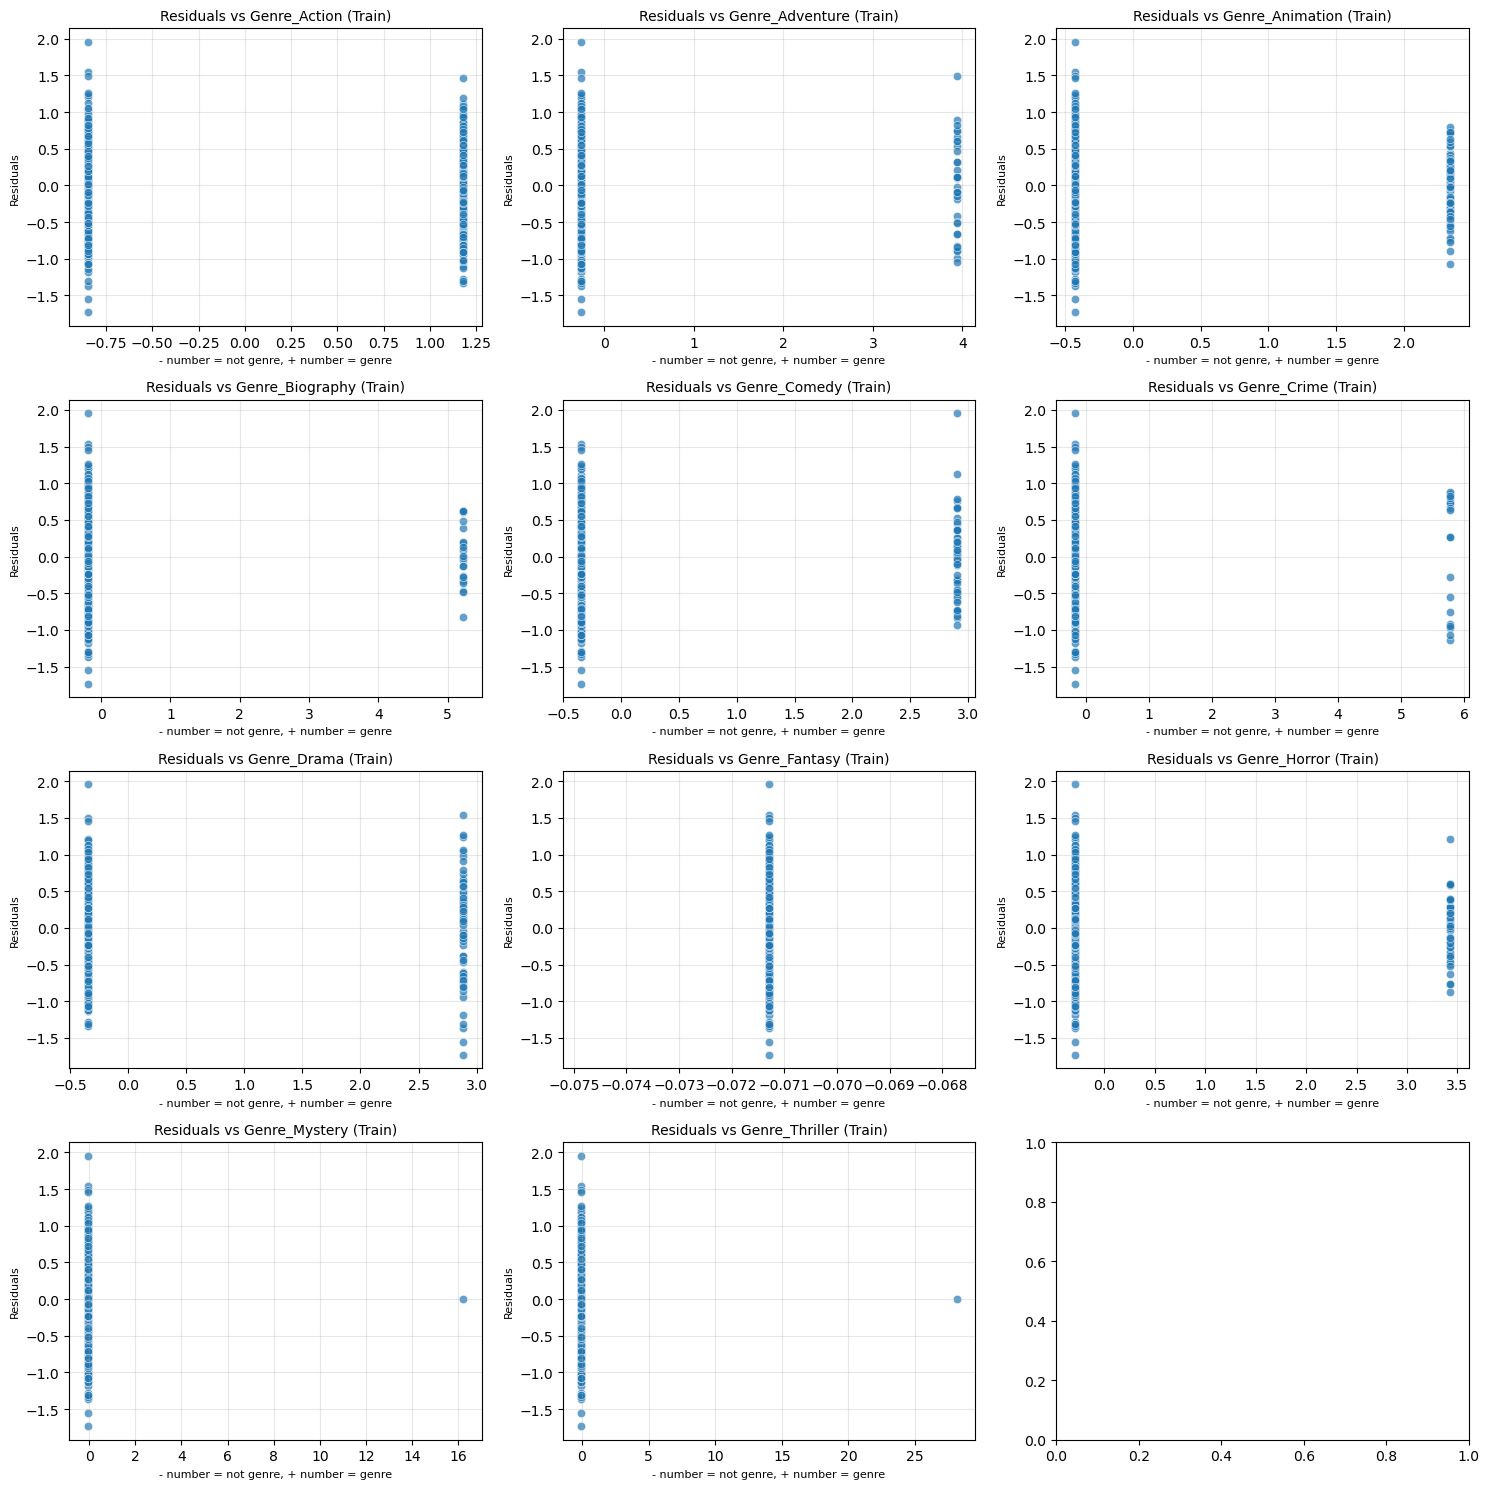

In [22]:
# Scatterplot for Residuals vs Genre
# For each genre, we make a subplot
# TRAIN DATA
# Make a dictionary with all indexes of Xtest needed and respective genres
genre_indexes = {
    3: 'Genre_Action',
    4: 'Genre_Adventure',
    5: 'Genre_Animation',
    6: 'Genre_Biography',
    7: 'Genre_Comedy',
    8: 'Genre_Crime',
    9: 'Genre_Drama',
    10: 'Genre_Fantasy',
    11: 'Genre_Horror',
    12: 'Genre_Mystery',
    13: 'Genre_Thriller',
}

fig, axes = plt.subplots(4, 3, figsize=(15, 15))
axes = axes.flatten()

for i, (index, genre) in enumerate(genre_indexes.items()):
    sns.scatterplot(x=Xtrain[:, index], y=train_residuals, alpha=0.7, ax=axes[i])
    axes[i].set_title(f"Residuals vs {genre} (Train)", fontsize=10)
    axes[i].set_xlabel("- number = not genre, + number = genre", fontsize=8)
    axes[i].set_ylabel("Residuals", fontsize=8)
    axes[i].grid(alpha=0.3)
    
plt.tight_layout()
plt.show()


### Residuals vs. Genres ($)

These 11 graphs detail the relationship between residuals and each genre. Every negative value represents a movie that isn't the respective genre, while every positive value represents a movie that is the respective genre. Every graph here follows a strict vertical trend, spread randomly around y=0, and there are no visible patterns in any of the graphs. Therefore, these graphs prove the assumption of linearity. However, there are small patterns outside of y axis distribution that show the effectiveness of the model in different genres. For example, the genre Drama seems to be the most inconsistent genre for the model, because the vertical spread of movies that are labeled 'Dramas' is very large. Therefore, it can be assumed that Drama movies have much more variance in IMDb ratings, thus the model cannot create accurate predictions. Horror also has a large distribution, but towards y>0, which shows that Horror is another tough genre for the model. Thriller is another interesting genre because none of the movies in the data set are thrillers, which is why there is only one line of residuals (negative). However, since there are a minimal number of outliers, the assumptions of linearity aren't broken, but it is important to note the weaknesses and strengths of the model.  

Note: The reason the one-hot encoded values are not strictly 0 and 1 is because of the standardization of values in the data set. However, the standardization of the data does not make values change sign, therefore all 'not a genre' values stay <= 0, and all 'is a genre' values stay > 0. 

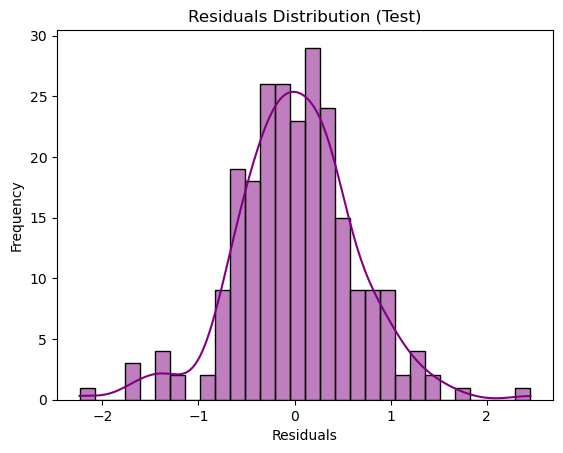

In [24]:
#Residual distribution to check normality
#TEST DATA
sns.histplot(residuals, kde=True, color="purple", bins=30)
plt.title("Residuals Distribution (Test)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

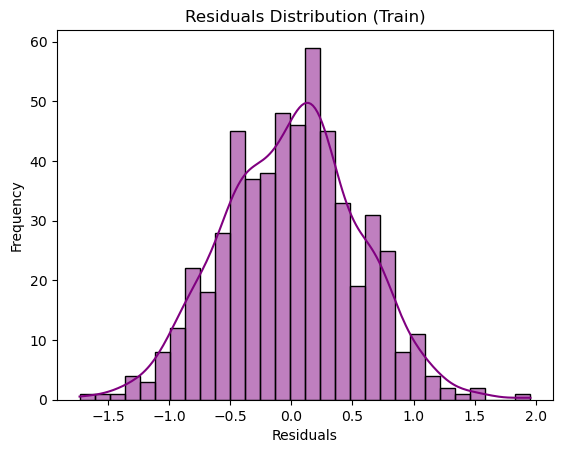

In [25]:
#Residual distribution to check normality
#TRAIN DATA
sns.histplot(train_residuals, kde=True, color="purple", bins=30)
plt.title("Residuals Distribution (Train)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

The residuals, for the most part, are distrbuted evenly along x=0 (the residuals axis is x in this graph). The shape of the histogram also follows the expected bell shape, confirming the assumption of normality. This confirmation of normality ensures even more relaitbility for the ridge model and also ensures that the model is capable of correctly predicting most independent variable input data. There are a few outliers, but no enough to discredit the assumption of normality. 

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Select relevant features and target column
df_second = df[['Year', 'IMDbRating', 'BoxOfficeEarnings ($)', 'Runtime (min)']]
df_second_drops = df_second.dropna()

# Step 2: Select relevant features and target
X = df_second_drops.drop(columns = ['IMDbRating']).values
y = df_second_drops['IMDbRating']  # Correct the column name here

# Step 3: Split the data into training and testing sets
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Transform features with PolynomialFeatures
poly = PolynomialFeatures(degree = 2, include_bias=False)
Xtrain_poly = poly.fit_transform(Xtrain)
Xtest_poly = poly.transform(Xtest)

# Step 5: Train the Polynomial Regression model
poly_reg_model = LinearRegression()
poly_reg_model.fit(Xtrain_poly, ytrain)

# Step 6: Make predictions on the test set
y_pred = poly_reg_model.predict(Xtest_poly)

# Step 7: Evaluate the model
mse = mean_squared_error(ytest, y_pred)
r2 = r2_score(ytest, y_pred)

# Display the results
print("Polynomial Regression Results")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")
print(f"Intercept: {poly_reg_model.intercept_}")
print(f"Coefficients: {poly_reg_model.coef_}")

Polynomial Regression Results


NameError: name 'degree' is not defined